# T23 — Debugging a plate model: feature extractability at subduction zones

**Cluster M: Plate-model debugging** (4 / 4).

## What this notebook does

Many downstream workflows built on top of GPlately + PlateTectonicTools sample **features at subduction-zone points** — convergence rate, obliquity, slab flux, distance-to-arc buffer zones, etc. See T15 and T16 for the porphyry-Cu case where 31 such features are computed at every deposit's paleo-position and fed into an ML model. These workflows depend on PTT's `subduction_convergence` (wrapped by `gplately.PlateReconstruction.tessellate_subduction_zones`) being able to compute per-point kinematics at every trench midpoint.

But PTT silently drops trench points where it can't work out the kinematics — typically because the subduction polarity is missing (see T22), or because the neighbouring plates aren't resolved at that time, or because the plate-ID assignment is ambiguous. The trench looks fine on a map, but if you feed it into a feature-extraction pipeline you get a big hole in your training data at exactly the wrong margin.

This notebook makes those holes visible:

1. **§1** Load plate model.
2. **§2** For each snapshot (100, 125, 150, 175, 200 Ma), draw the FULL trench line from resolved topologies AND overlay the successfully-extracted trench points from PTT. Anywhere the trench line exists but no extracted point sits on top of it is a **feature-extraction failure**.
3. **§3** Buffer-zone check: for each successfully-extracted trench point, build a small buffer polygon (default 200 km) on the over-riding side. Draw all buffers. Segments where NO buffer exists mark the same failure from the "downstream" perspective.
4. **§4** Compact MP4 video at 1-Myr cadence — animates how the extractable-vs-non-extractable pattern changes as topologies evolve.
5. **§5** Extend this — buffer distance, tessellation density, per-margin diagnostics.

**Reading the results.** A well-behaved plate model has extracted points along the ENTIRE length of every trench (no gaps). Real models always show some gaps — trenches with missing polarity (see T22), trenches at the model's time edge, or trenches at ambiguous triple junctions. The gaps are where any downstream ML/feature-extraction workflow is silently missing training data.

**Audience**: intermediate → researcher.
**Difficulty**: ★★★.
**Runtime**: ~1 min for 5 static snapshots; ~5-8 min for the 1-Myr video.


## Data availability

**Plate model** — Zahirovic 2022, fetched via PMM.

**Helper module** — `Notebooks/plate_model_debug/` (bundled with the suite).

## Sources

- Sculley, B. & Cannon, J. (2025) *plate-model-debug*. EarthByte, University of Sydney. Companion code for these tutorials.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146


## Environment + imports


In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
from shapely.geometry import LineString
import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager

sys.path.insert(0, str(Path("Notebooks").resolve()))
from plate_model_debug import calculate_plate_motion_arrows

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, gplately, pygmt, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  gplately    2.0.0.post19+git.2cce7bb3
  pygmt       v0.18.0
  pygplates   1.0.0


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0

SNAPSHOT_AGES_MA       = [100, 125, 150, 175, 200]

VIDEO_START_MA         = 200
VIDEO_END_MA           = 100
VIDEO_CADENCE_MA       = 1
VIDEO_FPS              = 10
VIDEO_WIDTH_PX         = 800
VIDEO_CRF              = 28

# Buffer-zone half-width in degrees (~ 200 km at the equator with 1° ~ 111 km).
BUFFER_DEG             = 2.0

# "Extraction gap" threshold: if a segment of trench is longer than this
# without a PTT-extracted point on it, flag it as an extraction failure.
GAP_THRESHOLD_DEG      = 3.0

REGION_GLOBAL          = [-180, 180, -75, 80]
PROJECTION             = "N15c"

FRAMES_DIR             = Path("Notebooks/T62_debug_extractability_frames")
VIDEO_DIR              = Path("Notebooks/videos")
VIDEO_PATH             = VIDEO_DIR / "T62_debug_extractability.mp4"
# Plate-motion vector overlay.
ARROW_SPACING_DEG      = 15.0     # grid spacing for arrow sampling (global 15° = readable, regional 3-5°)
ARROW_VEL_SCALE        = 0.08     # cm map length per cm/yr (map-projection-dependent; tune to taste)
ARROW_MIN_SPEED_CM_YR  = 0.5      # arrows below this speed are suppressed (removes near-stationary noise)

# ============================================================================
print(f"  plate model:  {MODEL_NAME}")
print(f"  snapshots:    {SNAPSHOT_AGES_MA} Ma")
print(f"  buffer:       ±{BUFFER_DEG}° (~{BUFFER_DEG*111:.0f} km at equator)")
print(f"  gap flag:     any trench segment > {GAP_THRESHOLD_DEG}° without extracted points")


  plate model:  Zahirovic2022
  snapshots:    [100, 125, 150, 175, 200] Ma
  buffer:       ±2.0° (~222 km at equator)
  gap flag:     any trench segment > 3.0° without extracted points


## 1. Load plate model


In [3]:
pmm = PlateModelManager()
model_pmm = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

_pmm_rot = model_pmm.get_rotation_model()
if not hasattr(_pmm_rot, "get_rotation"):
    rotation_model = pygplates.RotationModel(_pmm_rot)
else:
    rotation_model = _pmm_rot

topology_features = [pygplates.FeatureCollection(f) for f in model_pmm.get_topologies()]

topological_model = pygplates.TopologicalModel(topology_features, rotation_model)

recon = gplately.PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=model_pmm.get_topologies(),
    static_polygons=model_pmm.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  plate model loaded: {MODEL_NAME}")


  plate model loaded: Zahirovic2022


## 2. Compare full-trench geometry vs PTT-extracted trench points

Two operations at each snapshot:

- **Trench line geometry** — resolve topologies at `time` and collect every sub-segment whose feature type is `gpml_subduction_zone`. This is the FULL trench.
- **PTT-extracted trench points** — call `recon.tessellate_subduction_zones(time)`. This is what a downstream workflow ACTUALLY sees.

Anywhere the trench line exists but has no extracted point within `GAP_THRESHOLD_DEG` is an extraction failure.


In [4]:
def get_trench_geometry(time):
    """Return list of trench polylines (each an (N,2) array of lon,lat)."""
    resolved_topologies = []
    shared_boundary_sections = []
    pygplates.resolve_topologies(topology_features, rotation_model,
                                   resolved_topologies, float(time),
                                   shared_boundary_sections)
    trench_polylines = []
    for section in shared_boundary_sections:
        if section.get_feature().get_feature_type() != pygplates.FeatureType.gpml_subduction_zone:
            continue
        for ss in section.get_shared_sub_segments():
            for geom in ss.get_resolved_feature().get_geometries():
                pts = geom.to_lat_lon_array()  # (N, 2), lat then lon
                if len(pts) > 1:
                    trench_polylines.append(pts)
    return trench_polylines

def get_extracted_points(time):
    """Return (lon, lat) arrays for PTT-extractable trench points."""
    data = recon.tessellate_subduction_zones(float(time), ignore_warnings=True)
    if data is None or len(data) == 0:
        return np.array([]), np.array([])
    return np.asarray(data[:, 0], dtype=float), np.asarray(data[:, 1], dtype=float)

def find_extraction_gaps(trench_polylines, ext_lon, ext_lat, gap_deg=GAP_THRESHOLD_DEG):
    """Return list of (lon, lat) coordinate lists for trench segments that lack
    any extracted point within `gap_deg` degrees. Simple planar approximation —
    fine for this coarse diagnostic."""
    if len(ext_lon) == 0:
        # No extracted points: every trench polyline is a gap
        return [pl[:, [1, 0]] for pl in trench_polylines]
    ext_pts = np.column_stack([ext_lon, ext_lat])
    gaps = []
    for pl in trench_polylines:
        seg_lon = pl[:, 1]; seg_lat = pl[:, 0]
        seg_pts = np.column_stack([seg_lon, seg_lat])
        # For each polyline point, find nearest extracted point
        # (planar distance, degrees — coarse but fast).
        dmin = np.array([
            np.min(np.sqrt((ext_pts[:, 0] - p[0])**2 + (ext_pts[:, 1] - p[1])**2))
            for p in seg_pts
        ])
        # A polyline point is "in a gap" if the nearest extracted point is > gap_deg
        in_gap_mask = dmin > gap_deg
        if in_gap_mask.any():
            # Emit the sub-range(s) of the polyline that are in-gap
            in_gap = np.where(in_gap_mask)[0]
            # Split into contiguous runs
            runs = np.split(in_gap, np.where(np.diff(in_gap) != 1)[0] + 1)
            for run in runs:
                if len(run) >= 2:
                    gaps.append(np.column_stack([seg_lon[run], seg_lat[run]]))
    return gaps

# Quick sanity at 150 Ma
_pls = get_trench_geometry(150.0)
_elon, _elat = get_extracted_points(150.0)
_gaps = find_extraction_gaps(_pls, _elon, _elat)
_total_trench_pts = sum(len(p) for p in _pls)
_gap_pts = sum(len(g) for g in _gaps)
print(f"  150 Ma:")
print(f"    trench polylines from topology: {len(_pls)} ({_total_trench_pts} vertices)")
print(f"    PTT-extracted trench points:    {len(_elon)}")
print(f"    extraction-gap segments:        {len(_gaps)} ({_gap_pts} vertices)")


  150 Ma:
    trench polylines from topology: 50 (373 vertices)
    PTT-extracted trench points:    10682
    extraction-gap segments:        0 (0 vertices)


## 3. Static snapshots at 100, 125, 150, 175, 200 Ma

Colour coding:

- **Grey lines** — full trench geometry from resolved topologies
- **Green dots** — PTT-extracted trench points (successful)
- **Red thick lines** — trench segments where extraction fails (any polyline stretch without a successful extraction within `GAP_THRESHOLD_DEG`)
- **Faint blue polygons** — buffer zones (a downstream feature-extraction primitive; missing where extraction fails)


  rendering 100 Ma ...


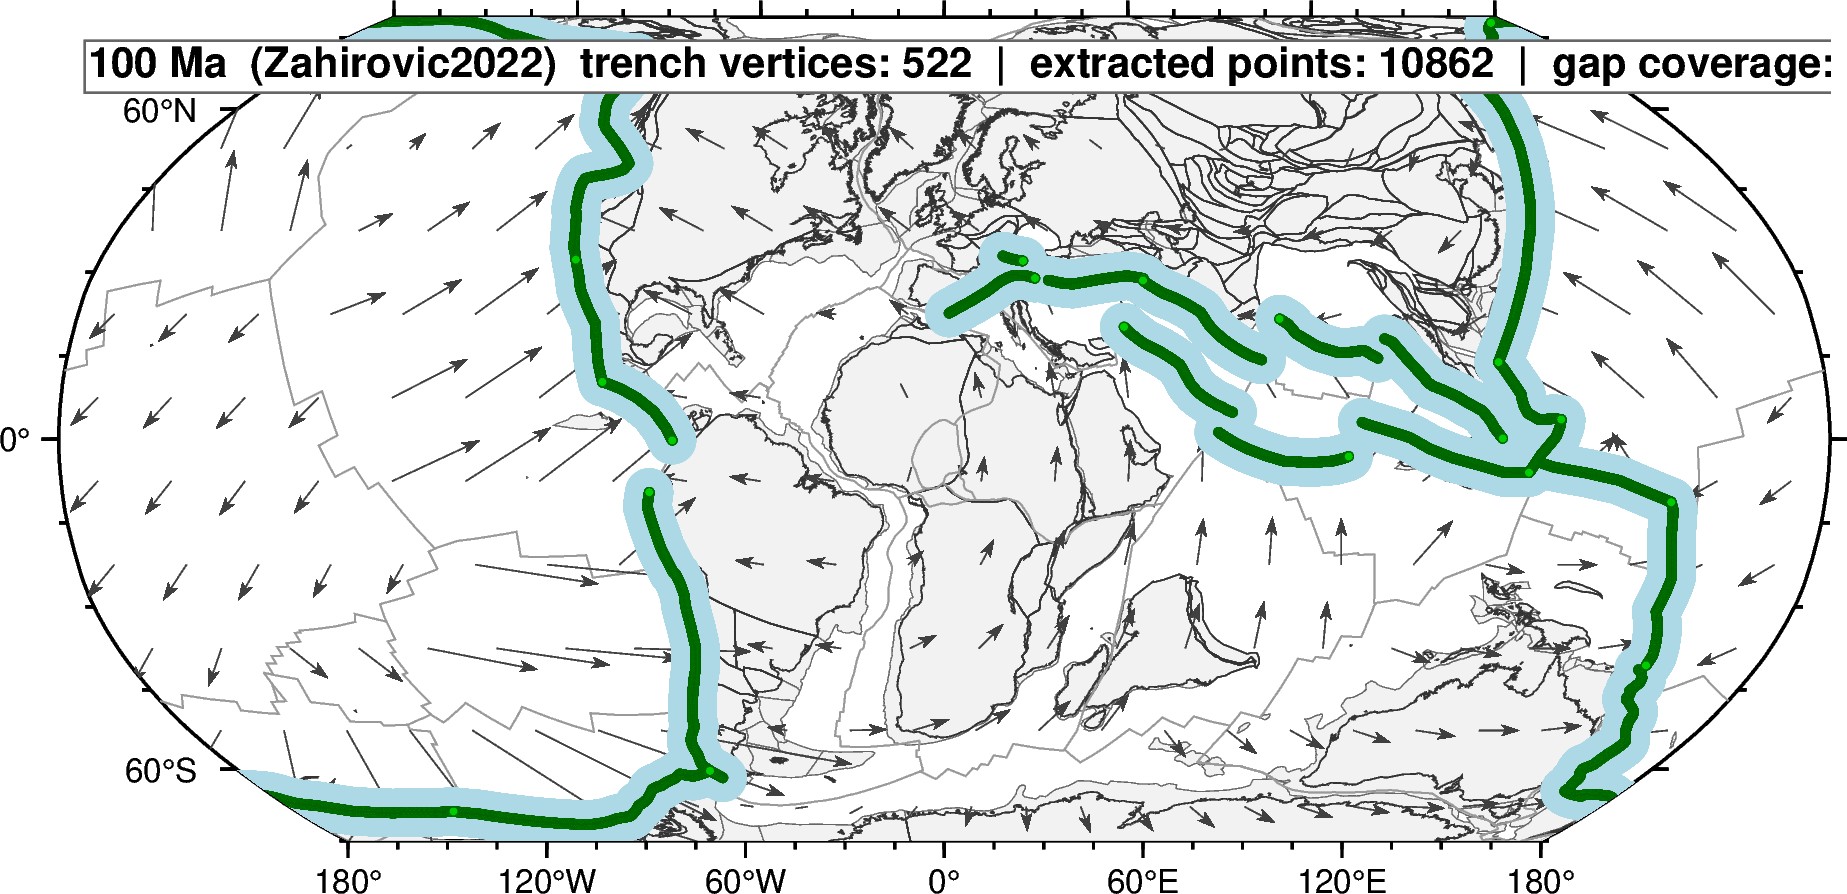

  rendering 125 Ma ...


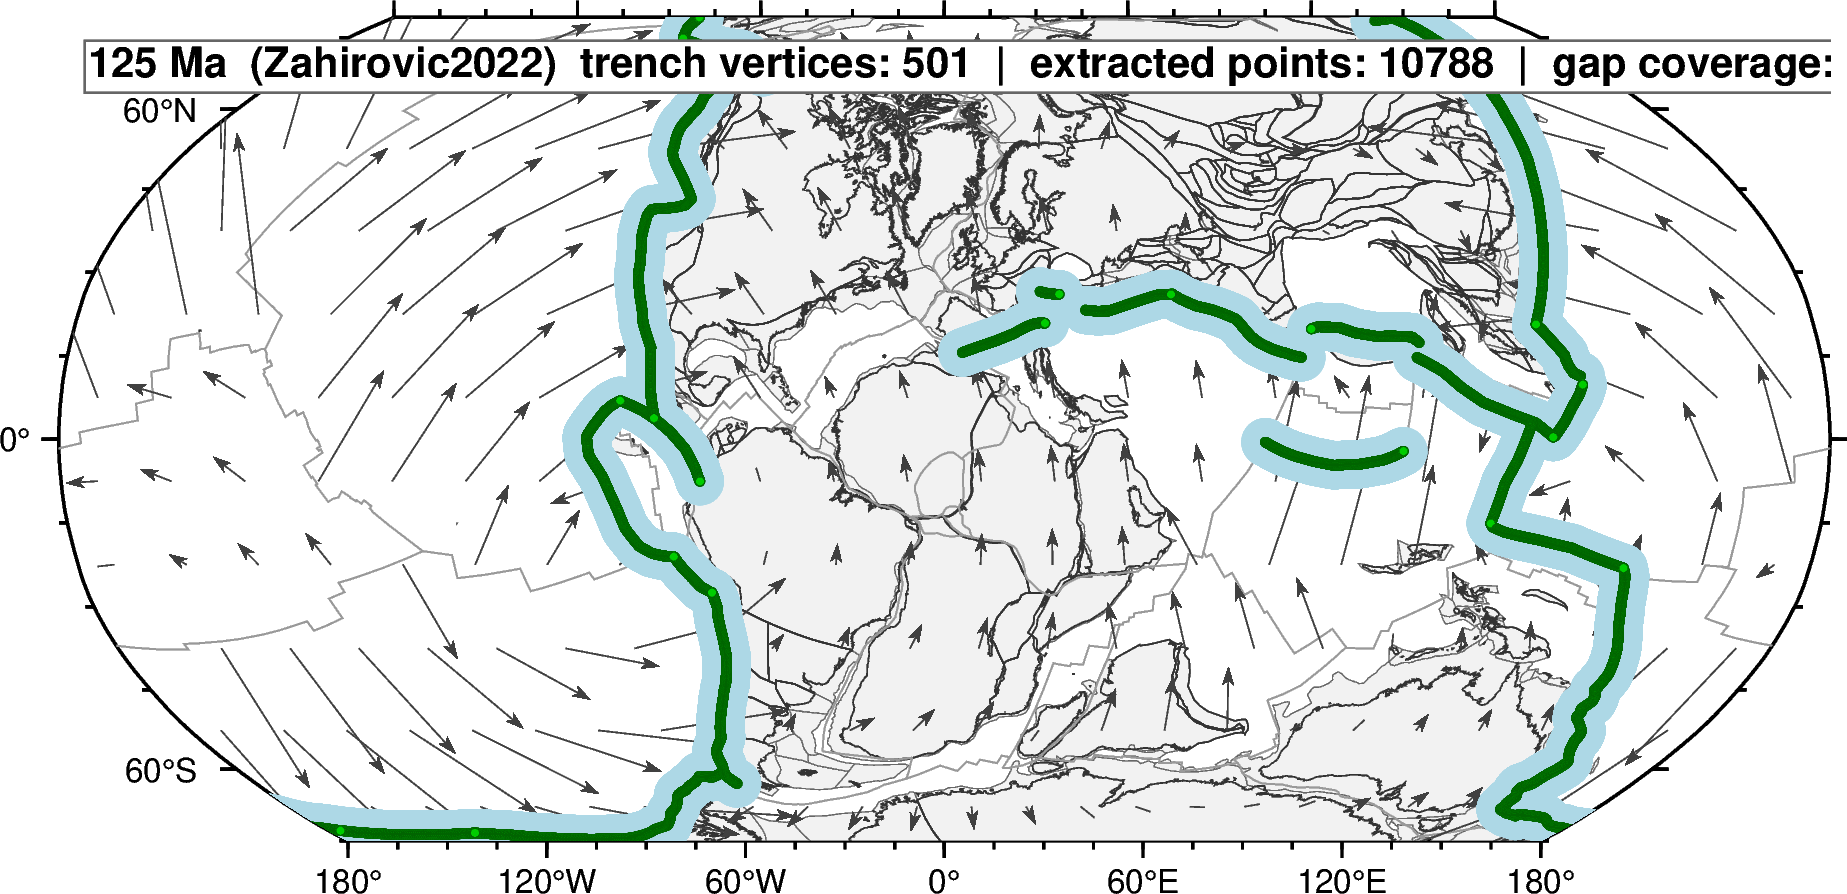

  rendering 150 Ma ...


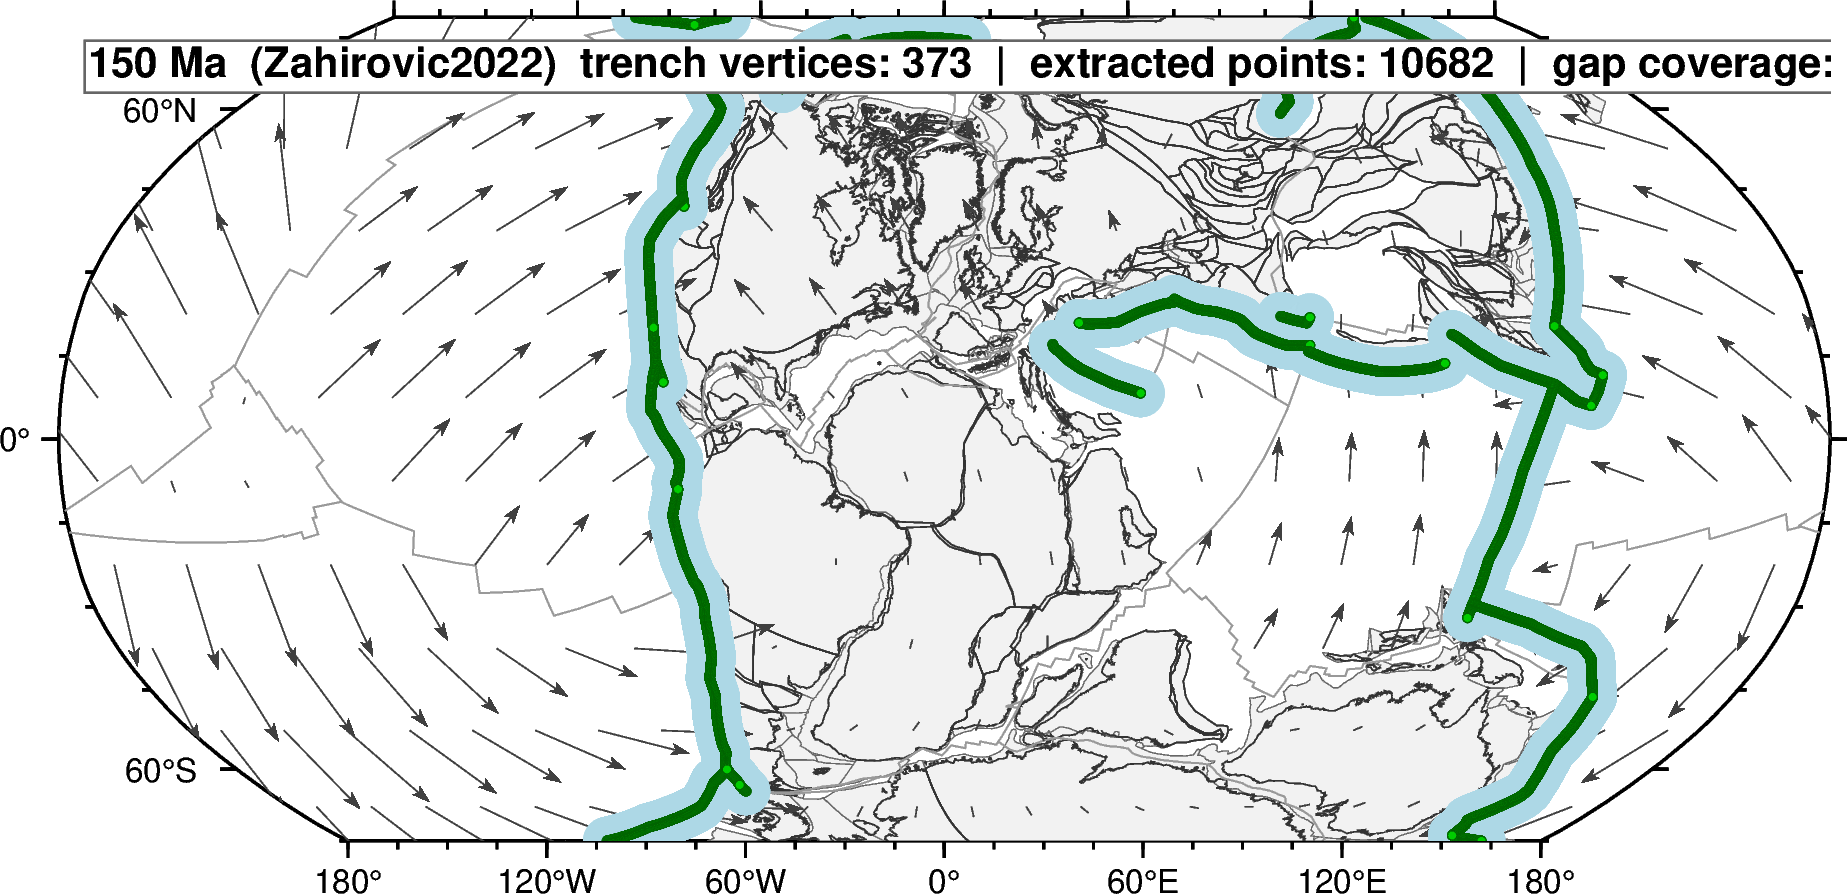

  rendering 175 Ma ...


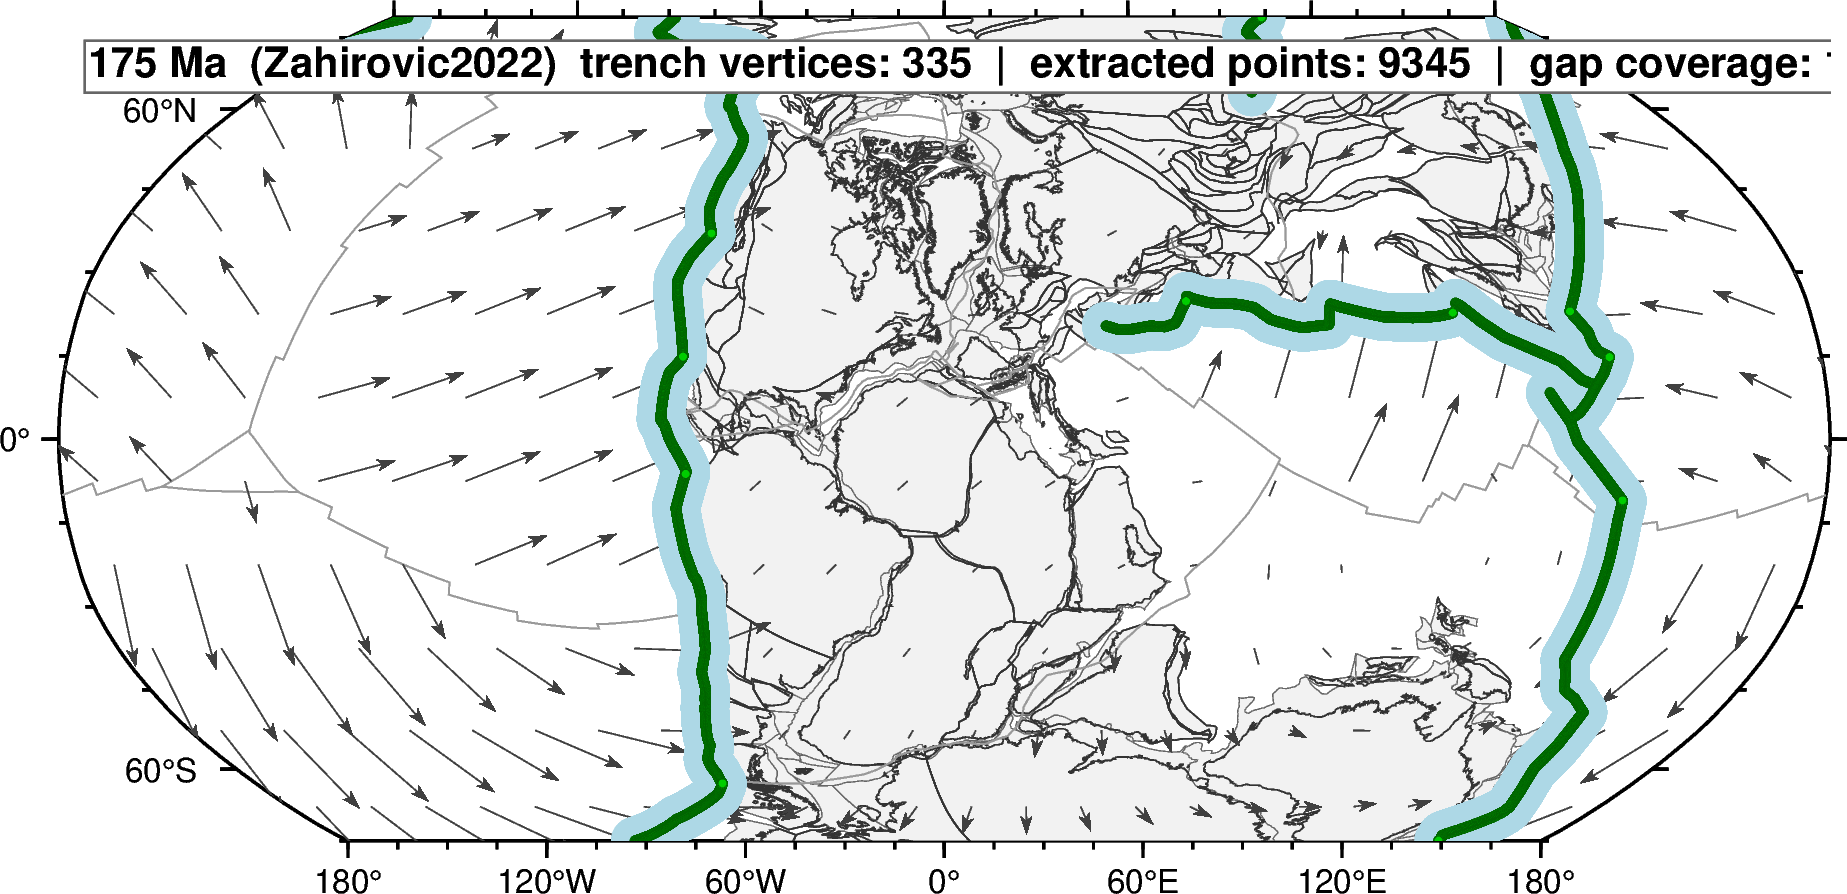

  rendering 200 Ma ...


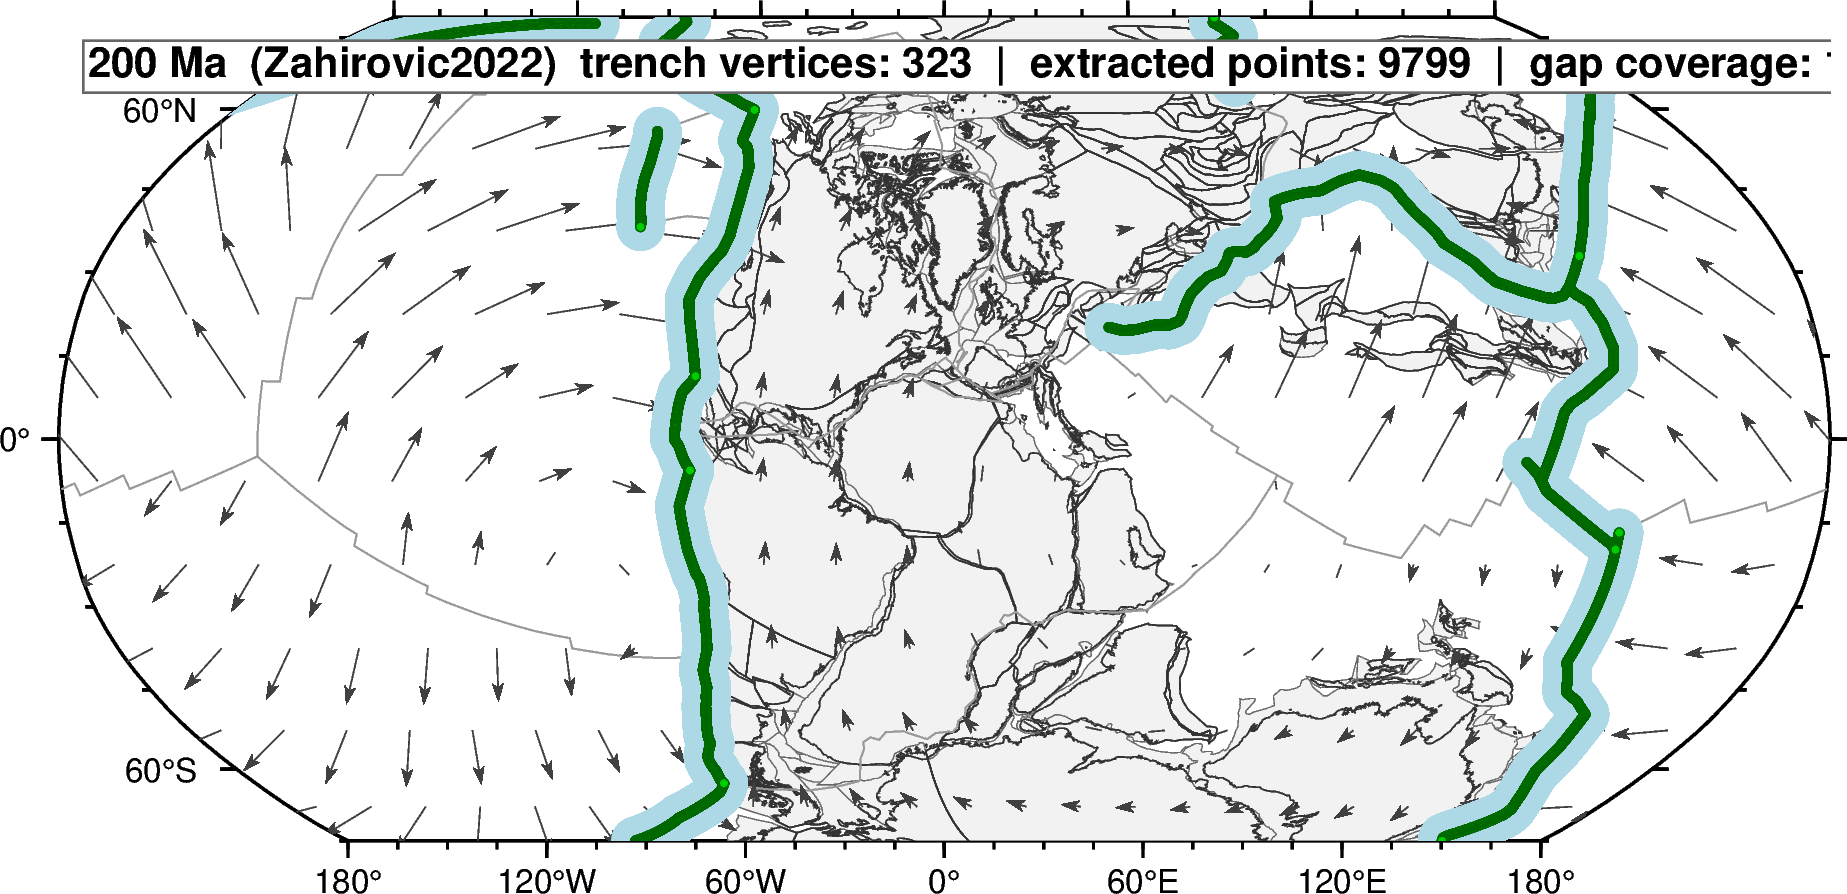

In [5]:
def render_extractability_map(time, out_path=None, width_cm=15):
    trench_polylines = get_trench_geometry(time)
    ext_lon, ext_lat = get_extracted_points(time)
    gaps = find_extraction_gaps(trench_polylines, ext_lon, ext_lat)

    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model_pmm.get_coastlines(),
        continents=model_pmm.get_continental_polygons(),
        COBs=model_pmm.get_COBs(),
        time=float(time),
        plot_engine=gplately.PygmtPlotEngine(),
    )

    fig = pygmt.Figure()
    fig.basemap(region=REGION_GLOBAL, projection=f"N{width_cm}c", frame=["af", "WSne"])

    try:
        gplot.plot_continents(fig, fill="gray95", pen="0.2p,gray40")
        gplot.plot_coastlines(fig, pen="0.3p,gray20")
    except Exception:
        pass

    try:
        engine = gplately.PygmtPlotEngine()
        engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                                    pen="0.35p,gray60")
    except Exception:
        pass

    # --- Plate-motion vector overlay (dark-grey arrows under the anomaly layer)
    try:
        _snap = topological_model.topological_snapshot(float(time))
        _alons, _alats, _ae, _an = calculate_plate_motion_arrows(
            _snap, region=REGION_GLOBAL, spacing_deg=ARROW_SPACING_DEG)
        if len(_alons):
            _speed = np.sqrt(_ae ** 2 + _an ** 2)
            _azimuth = np.rad2deg(np.arctan2(_ae, _an))
            _m = _speed >= ARROW_MIN_SPEED_CM_YR
            if _m.any():
                fig.plot(x=_alons[_m], y=_alats[_m],
                          style="V0.15c+e+a35",
                          direction=[_azimuth[_m], ARROW_VEL_SCALE * _speed[_m]],
                          fill="gray25", pen="0.3p,gray25")
    except Exception as _e:
        print(f"    (skip velocity arrows: {type(_e).__name__}: {_e})")


    # Full trench geometry (grey lines under everything else)
    for pl in trench_polylines:
        fig.plot(x=pl[:, 1], y=pl[:, 0], pen="0.8p,gray30")

    # Buffer zones (built as symmetric ±BUFFER_DEG rectangles around each ext point;
    # coarse approximation of an over-riding-plate buffer zone).
    if len(ext_lon) > 0:
        try:
            # Represent buffer as small circles rendered under the extracted points
            fig.plot(x=ext_lon, y=ext_lat,
                      style=f"c{2*BUFFER_DEG*0.1}c",
                      fill="lightblue@70", pen="0.2p,lightblue")
        except Exception:
            pass

    # Extracted trench points (green dots)
    if len(ext_lon) > 0:
        fig.plot(x=ext_lon, y=ext_lat, style="c0.08c",
                  fill="green3", pen="0.2p,darkgreen")

    # Gap segments (thick red lines on top)
    for g in gaps:
        fig.plot(x=g[:, 0], y=g[:, 1], pen="2p,red")

    n_ext = len(ext_lon)
    n_trench_verts = sum(len(pl) for pl in trench_polylines)
    n_gap_verts = sum(len(g) for g in gaps)
    coverage_pct = 100 * (1 - n_gap_verts / n_trench_verts) if n_trench_verts else 0

    fig.text(text=f"{int(time)} Ma  ({MODEL_NAME})  "
                   f"trench vertices: {n_trench_verts}  |  "
                   f"extracted points: {n_ext}  |  "
                   f"gap coverage: {coverage_pct:.1f}%",
              position="TL", offset="0.25c/-0.25c", justify="TL",
              font="10p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")

    if out_path is not None:
        fig.savefig(str(out_path), dpi=100)
        return None
    return fig

for _age in SNAPSHOT_AGES_MA:
    print(f"  rendering {_age} Ma ...")
    _f = render_extractability_map(_age, width_cm=15)
    _f.show(width=900)


### How to read these maps

- **Grey lines** show every trench the plate model draws. This is what you'd see if you loaded the topology GPMLs into GPlates and turned on the "SubductionZone" feature type.
- **Green dots** are the trench points PTT actually managed to compute features for. In a healthy trench, they hug the grey line all the way along its length.
- **Red thick lines** are stretches of grey trench with no nearby green dot. These are the extraction failures. Downstream feature-extraction workflows silently miss data here.
- **Faint blue circles** around each green dot are placeholder markers for the buffer-zone-per-extracted-point primitive that downstream workflows build. Missing at any red segment.
- **Gap coverage percentage** in the title stamp — headline number. 100% = every trench vertex has a nearby extracted point. Below 90% = something's wrong; investigate.

**Watch for**

- **Long red segments** — big chunks of trench where extraction is failing systematically. Often a plate ID or a missing polarity issue (see T22).
- **Coverage < 90%** at some ages but > 98% at others — indicates a specific topology-construction issue that only kicks in at certain ages.
- **Modern-day snapshot vs Mesozoic** — modern (0 Ma) should have very high coverage in most models; anything old-Mesozoic where coverage drops means the constraints are weaker.


## 4. Compact MP4 video at 1-Myr cadence over 100-200 Ma


In [6]:
FRAMES_DIR.mkdir(exist_ok=True, parents=True)
VIDEO_DIR.mkdir(exist_ok=True, parents=True)

_target_dpi = 100
_frame_width_cm = VIDEO_WIDTH_PX / _target_dpi * 2.54

ages_desc = np.arange(VIDEO_END_MA, VIDEO_START_MA + 1e-6, VIDEO_CADENCE_MA)[::-1]
print(f"  will render {len(ages_desc)} frames at ~{VIDEO_WIDTH_PX} px wide")

frame_paths = []
for i, _age in enumerate(ages_desc):
    _p = FRAMES_DIR / f"frame_{int(round(_age)):04d}Ma.png"
    if not _p.exists():
        render_extractability_map(float(_age), out_path=_p, width_cm=_frame_width_cm)
    if i % 10 == 0:
        print(f"    frame {i+1}/{len(ages_desc)}  ({int(round(_age))} Ma)")
    frame_paths.append(_p)
print(f"  ✓ {len(frame_paths)} frames on disk")

import imageio.v2 as imageio
writer = imageio.get_writer(
    str(VIDEO_PATH), fps=VIDEO_FPS, codec="libx264",
    ffmpeg_params=["-crf", str(VIDEO_CRF), "-preset", "veryfast", "-pix_fmt", "yuv420p"],
)
for _p in frame_paths:
    writer.append_data(imageio.imread(str(_p)))
writer.close()
print(f"  ✓ wrote {VIDEO_PATH}  ({VIDEO_PATH.stat().st_size / 1e6:.1f} MB)")

from IPython.display import Video
Video(str(VIDEO_PATH), embed=True, width=VIDEO_WIDTH_PX)


  will render 101 frames at ~800 px wide
    frame 1/101  (200 Ma)
    frame 11/101  (190 Ma)
    frame 21/101  (180 Ma)
    frame 31/101  (170 Ma)
    frame 41/101  (160 Ma)
    frame 51/101  (150 Ma)
    frame 61/101  (140 Ma)
    frame 71/101  (130 Ma)
    frame 81/101  (120 Ma)
    frame 91/101  (110 Ma)
    frame 101/101  (100 Ma)
  ✓ 101 frames on disk
2026-07-16 12:26:17 - imageio_ffmpeg - WARNING - IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (826, 396) to (832, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


[vost#0:0/libx264 @ 0x125804530] Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


  ✓ wrote Notebooks/videos/T62_debug_extractability.mp4  (0.8 MB)


## Extend this

- **Cross-reference against T22.** For each red gap segment, check whether a T22 missing-polarity dot is nearby. If so, that specific trench needs its polarity set. Fix the polarity, re-run T23, watch the coverage percentage climb.
- **Denser buffer zones.** Set `BUFFER_DEG` lower (e.g. 1° ≈ 100 km) for finer-grained buffer geometry, or higher (e.g. 5° ≈ 500 km) for coarser regional analysis.
- **Wider gap tolerance.** Set `GAP_THRESHOLD_DEG` higher (e.g. 5°) if you only care about SIGNIFICANT extraction failures and can tolerate short gaps around triple junctions.
- **Regional coverage stats.** Compute the per-margin extraction coverage (Andes, SW Pacific, Tethyan, Panthalassa) so you can see which specific margin is the weak spot for your downstream analysis.
- **Sample your own points.** If you have a set of deposit / sample locations you want to run a feature-extraction workflow against, plot them on top and see which land on green (extractable) vs red (extraction fails) segments. This gives you a direct assessment of whether the plate model is fit for your dataset.

## Related resources

- PlateTectonicTools: <https://github.com/EarthByte/PlateTectonicTools>.
- Companion notebooks: **T20** sign-anomalies at boundaries, **T21** velocity magnitude at MORs, **T22** topology construction anomalies.
- T15 and T16 (mineral-exploration cluster) — downstream consumers of trench-point feature extraction.

## References

- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146
- Mather, B.R., et al. (2024) Deep time spatio-temporal data analysis using pyGPlates with PlateTectonicTools and GPlately. *Applied Computing and Geosciences* 22, 100152.
